# Week 7 Mini Project 1

## Predicting Employee Attrition Using Classification Models

Dataset path: `data/WA_Fn-UseC_-HR-Employee-Attrition.csv`

## Environment Setup

This project uses the dependency file `requirements.txt`.

Run the next cell inside Jupyter to install the required packages into the active notebook environment.

After that, make sure Jupyter is using the `.venv` kernel.

In [14]:
# Run this once in Jupyter if the notebook shows ModuleNotFoundError.
import sys
print(sys.executable)
%pip install -r requirements.txt

/opt/homebrew/Cellar/jupyterlab/4.2.5/libexec/bin/python

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.2.5/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries

In [15]:
# Show which Python executable the notebook kernel is using.
# If this path is not inside `.venv`, switch the Jupyter kernel before continuing.
import sys
print(sys.executable)

# Suppress non-critical warnings to keep notebook output readable.
import warnings

# Save the final trained model as model.pkl for submission.
import joblib
# Plot charts for attrition distribution, feature analysis, and model evaluation.
import matplotlib.pyplot as plt
# Support numerical operations during preprocessing and analysis.
import numpy as np
# Load and manipulate the IBM HR attrition dataset.
import pandas as pd
# Create cleaner statistical plots for EDA.
import seaborn as sns
# Apply different preprocessing steps to numeric and categorical columns.
from sklearn.compose import ColumnTransformer
# Fill missing values if any appear in the dataset or derived features.
from sklearn.impute import SimpleImputer
# Build a linear baseline classifier for attrition prediction.
from sklearn.linear_model import LogisticRegression
# Measure classification quality beyond accuracy for imbalanced attrition data.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
# Split data fairly and optionally tune model hyperparameters.
from sklearn.model_selection import GridSearchCV, train_test_split
# Combine preprocessing and modeling into a single reproducible workflow.
from sklearn.pipeline import Pipeline
# Encode text categories and scale numeric features for models like logistic regression and SVM.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Train a non-linear classifier required by the assignment.
from sklearn.svm import SVC
# Train a tree-based model and inspect feature importance.
from sklearn.tree import DecisionTreeClassifier

# Notebook display settings.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

/opt/homebrew/Cellar/jupyterlab/4.2.5/libexec/bin/python


### Kernel Setup Note

If you get `ModuleNotFoundError`, do this before continuing:

1. Activate the project virtual environment.
2. Install the required packages from `requirements.txt`.
3. Register the virtual environment as a Jupyter kernel.
4. Switch the notebook kernel to that `.venv` kernel.

Run these commands in the terminal:

```bash
source .venv/bin/activate
pip install -r requirements.txt
python -m ipykernel install --user --name iitm-attrition --display-name "Python (.venv iitm-attrition)"
```

Then in Jupyter, select the kernel named `Python (.venv iitm-attrition)`.

## 2. Load Dataset

In [16]:
# Define the CSV path for the IBM HR attrition dataset used in this assignment.
data_path = "data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the dataset into a pandas DataFrame for analysis and modeling.
df = pd.read_csv(data_path)

# Inspect basic dataset details before starting EDA.
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

# Preview the first few rows to confirm the file loaded correctly.
df.head()

Dataset shape: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Exploratory Data Analysis

Substeps for this section:

1. Check dataset shape, column names, and data types.
2. Display `df.head()` and `df.describe()`.
3. Check missing values for all columns.
4. Check duplicate rows.
5. Analyze the target column `Attrition`.
6. Confirm whether the classes are imbalanced.
7. Separate numerical and categorical columns.
8. Plot a countplot for `Attrition`.
9. Plot histograms for `Age`, `MonthlyIncome`, and `TotalWorkingYears`.
10. Plot boxplots to inspect outliers.
11. Plot a correlation heatmap for numerical columns.
12. Compare attrition against `OverTime`, `JobRole`, `WorkLifeBalance`, and `JobSatisfaction`.
13. Write 3-5 short observations summarizing the main EDA findings.

Dataset shape: (1470, 35)

Data types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWork

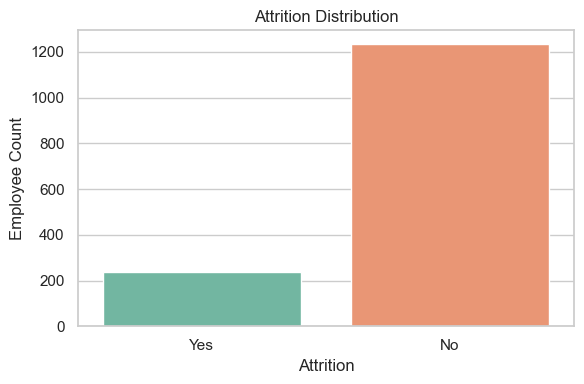

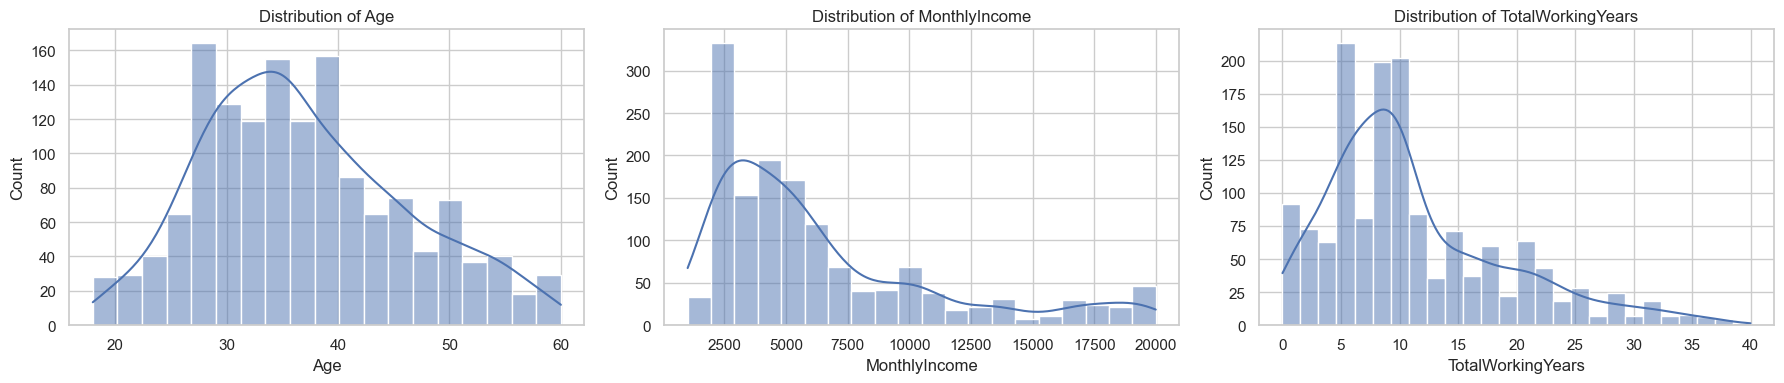

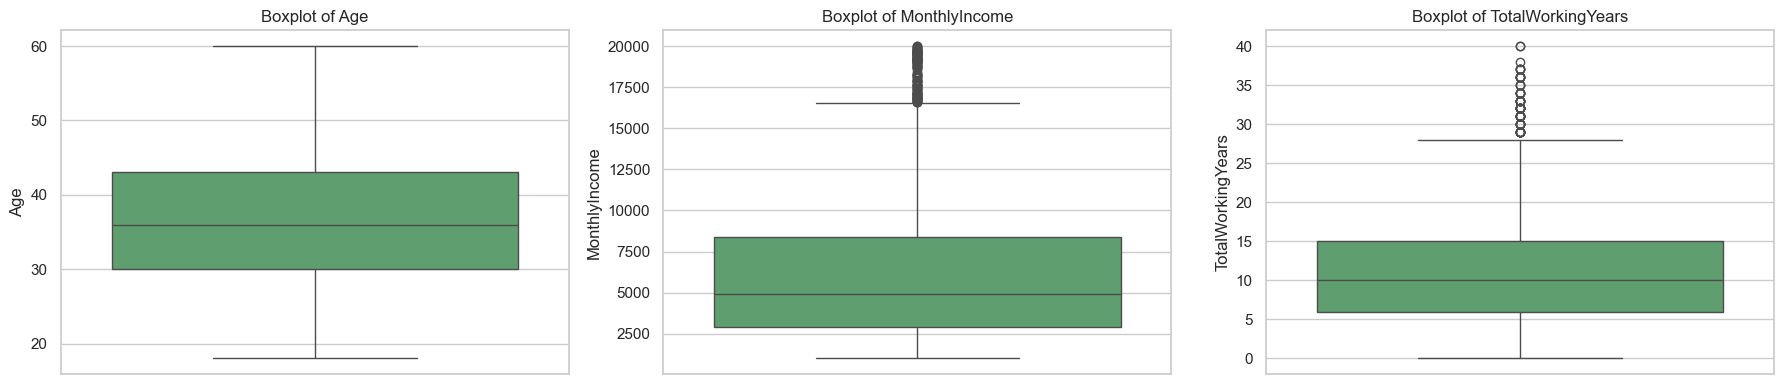

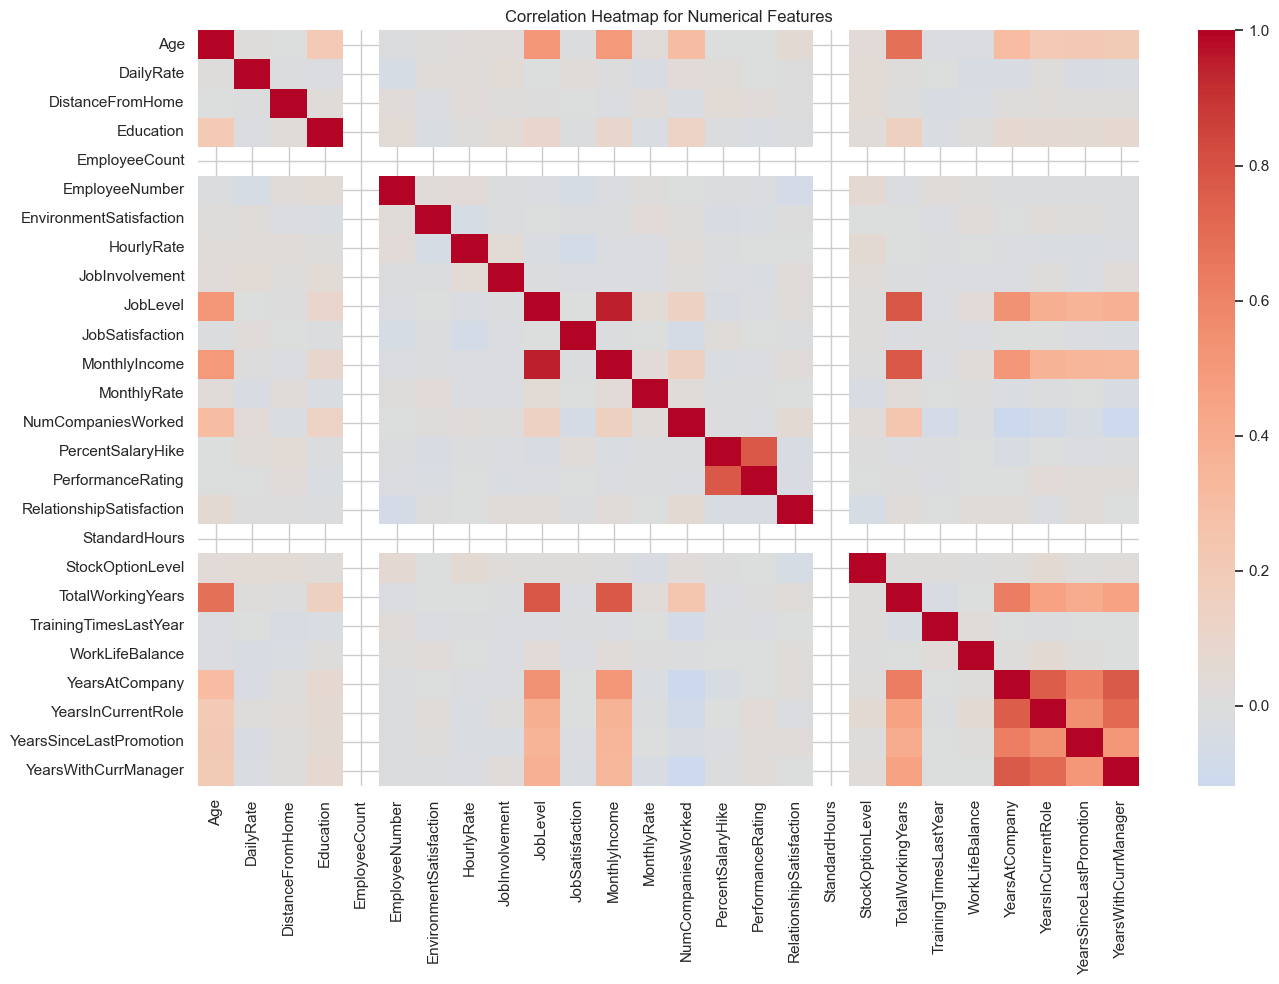

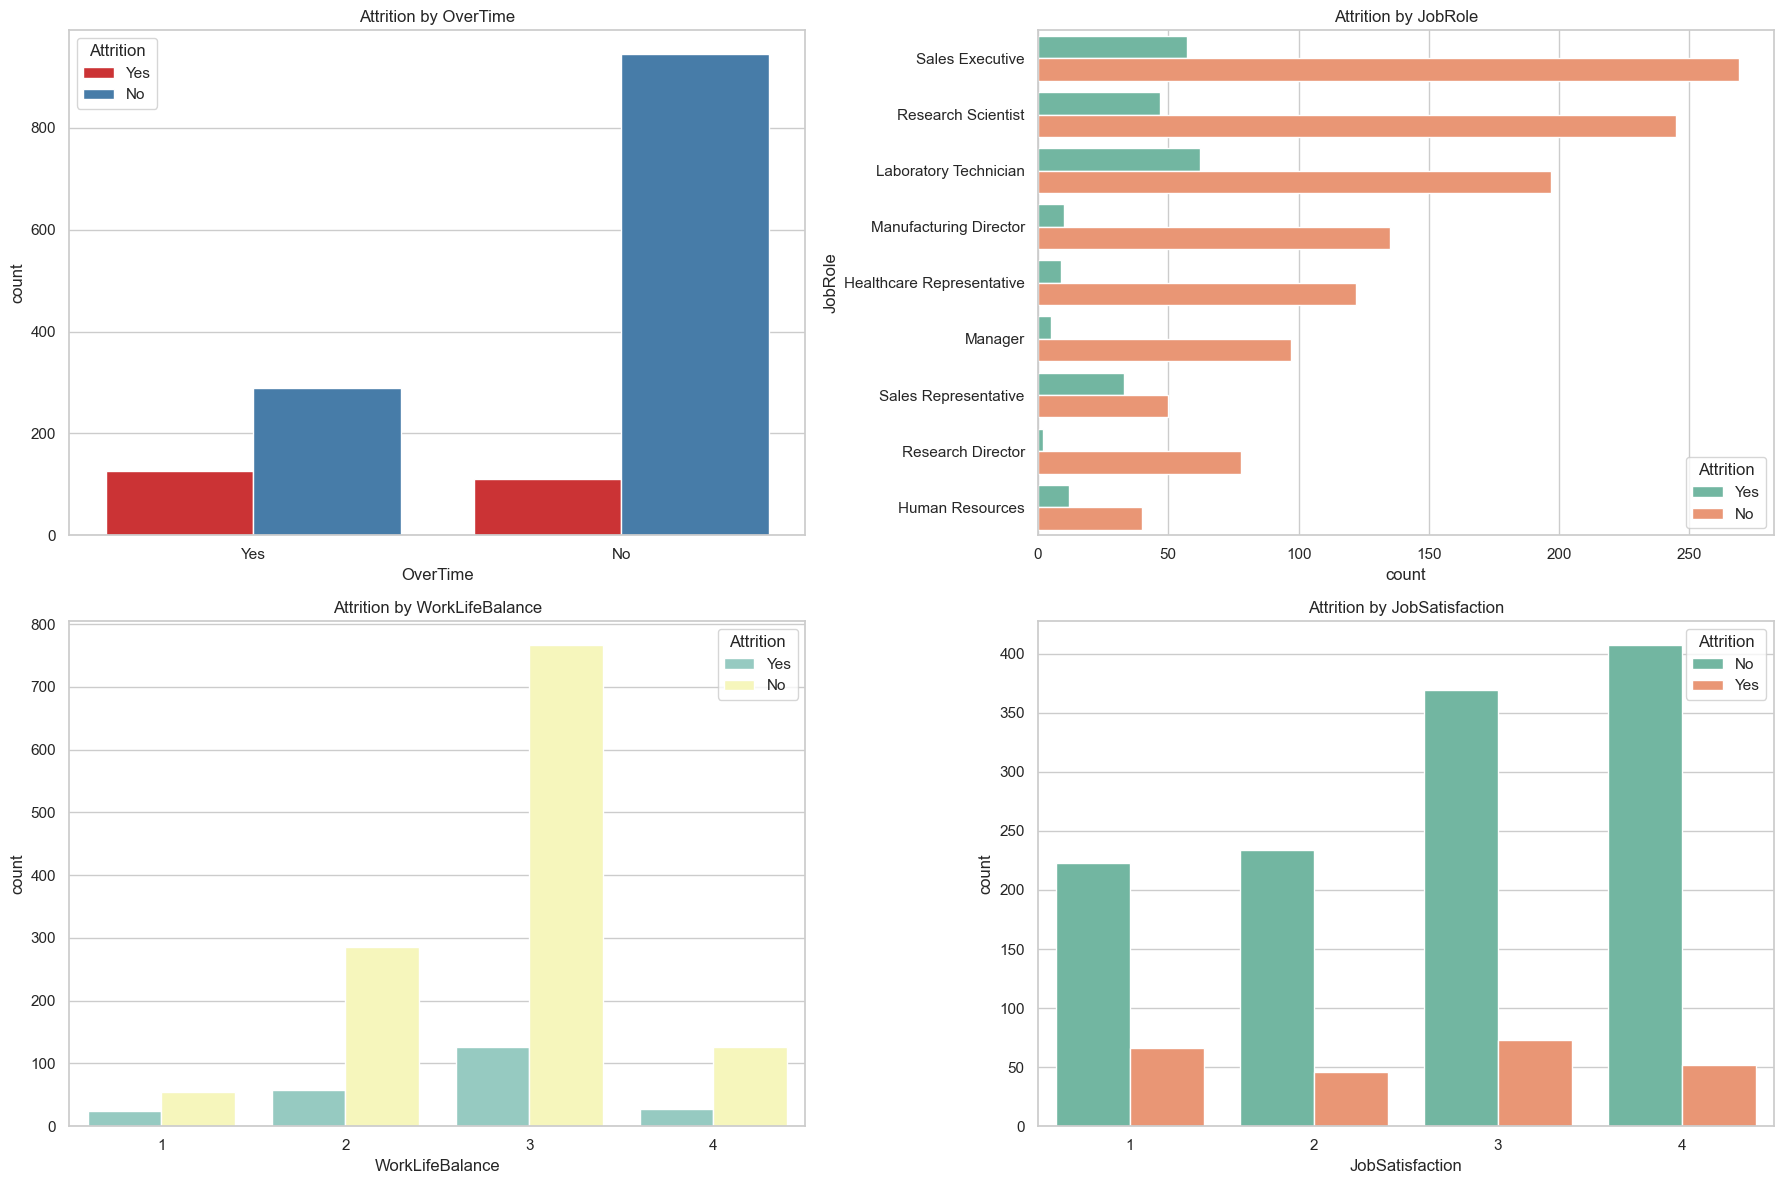


EDA observations:
1. Overall attrition rate is 16.12% compared with 83.88% retention.
2. Employees working overtime have a higher attrition rate (30.53%) than those who do not (10.44%).
3. The highest attrition rate appears in the job role 'Sales Representative' at 39.76%.
4. The most at-risk work-life balance rating is 1 with attrition rate 31.25%.
5. Average monthly income is 4787.09 for employees who left versus 6832.74 for employees who stayed.


In [17]:
# Review the dataset structure before preprocessing.
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head().to_string())

print("\nSummary statistics for numerical columns:")
print(df.describe().to_string())

# Check data quality issues.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

print("\nMissing values by column:")
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "No missing values found.")
print(f"\nDuplicate rows: {duplicate_rows}")

# Study the target column and confirm class imbalance.
attrition_counts = df["Attrition"].value_counts()
attrition_percentages = df["Attrition"].value_counts(normalize=True).mul(100).round(2)

print("\nAttrition counts:")
print(attrition_counts)
print("\nAttrition percentages:")
print(attrition_percentages)

minority_ratio = attrition_counts.min() / attrition_counts.max()
print(f"\nMinority-to-majority ratio: {minority_ratio:.2f}")
if minority_ratio < 0.50:
    print("The target classes are imbalanced.")
else:
    print("The target classes are relatively balanced.")

# Separate numerical and categorical columns for focused analysis.
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumber of numerical columns:", len(numerical_columns))
print("Numerical columns:", numerical_columns)
print("\nNumber of categorical columns:", len(categorical_columns))
print("Categorical columns:", categorical_columns)

# Countplot for the target column.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition", hue="Attrition", palette="Set2", legend=False)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

# Histograms for key numerical features.
key_numerical_features = ["Age", "MonthlyIncome", "TotalWorkingYears"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, key_numerical_features):
    sns.histplot(data=df, x=column, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

# Boxplots for outlier inspection.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, key_numerical_features):
    sns.boxplot(data=df, y=column, ax=ax, color="#55A868")
    ax.set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

# Correlation heatmap for numerical columns.
plt.figure(figsize=(14, 10))
correlation_matrix = df[numerical_columns].corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

# Compare attrition with important business features.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.countplot(data=df, x="OverTime", hue="Attrition", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Attrition by OverTime")

jobrole_order = df["JobRole"].value_counts().index
sns.countplot(data=df, y="JobRole", hue="Attrition", order=jobrole_order, palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title("Attrition by JobRole")

sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition", palette="Set3", ax=axes[1, 0])
axes[1, 0].set_title("Attrition by WorkLifeBalance")

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("Attrition by JobSatisfaction")

for ax in axes.flat:
    ax.legend(title="Attrition")
plt.tight_layout()
plt.show()

# Summarize a few business-relevant observations from the EDA.
attrition_flag = (df["Attrition"] == "Yes").astype(int)
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).round(2)
jobrole_attrition = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
worklife_attrition = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
income_by_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(2)

print("\nEDA observations:")
print(f"1. Overall attrition rate is {attrition_percentages['Yes']:.2f}% compared with {attrition_percentages['No']:.2f}% retention.")
print(f"2. Employees working overtime have a higher attrition rate ({overtime_attrition.get('Yes', 0):.2f}%) than those who do not ({overtime_attrition.get('No', 0):.2f}%).")
print(f"3. The highest attrition rate appears in the job role '{jobrole_attrition.index[0]}' at {jobrole_attrition.iloc[0]:.2f}%.")
print(f"4. The most at-risk work-life balance rating is {worklife_attrition.index[0]} with attrition rate {worklife_attrition.iloc[0]:.2f}%.")
print(f"5. Average monthly income is {income_by_attrition['Yes']:.2f} for employees who left versus {income_by_attrition['No']:.2f} for employees who stayed.")

### 3.12 Split EDA Workflow

The cells below break the EDA into separate runnable steps so each check and plot can be executed independently.

### 3.12.1 Dataset Structure

Review the shape, data types, and first few rows to confirm the dataset loaded correctly.

In [ ]:
print(f"Dataset shape: {df.shape}")
print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head().to_string())

### 3.12.2 Summary Statistics

Use descriptive statistics to understand the spread and range of numerical features.

In [ ]:
print(df.describe().to_string())

### 3.12.3 Missing Values And Duplicates

Check the dataset for null values and duplicate rows before doing model work.

In [ ]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "No missing values found.")
print(f"\nDuplicate rows: {duplicate_rows}")

### 3.12.4 Target Distribution

Measure attrition counts and percentages to confirm the class imbalance.

In [ ]:
attrition_counts = df["Attrition"].value_counts()
attrition_percentages = df["Attrition"].value_counts(normalize=True).mul(100).round(2)
minority_ratio = attrition_counts.min() / attrition_counts.max()

print(attrition_counts)
print("\nAttrition percentages:")
print(attrition_percentages)
print(f"\nMinority-to-majority ratio: {minority_ratio:.2f}")
print("The target classes are imbalanced." if minority_ratio < 0.50 else "The target classes are relatively balanced.")

### 3.12.5 Column Types

Separate numerical and categorical columns because later preprocessing will handle them differently.

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
key_numerical_features = ["Age", "MonthlyIncome", "TotalWorkingYears"]

print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)

### 3.12.6 Attrition Count Plot

Visualize the target distribution directly.

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition", hue="Attrition", palette="Set2", legend=False)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()

### 3.12.7 Histograms

Plot key numerical features to inspect their distributions.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, key_numerical_features):
    sns.histplot(data=df, x=column, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

### 3.12.8 Boxplots

Inspect outliers in the main numerical features.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, key_numerical_features):
    sns.boxplot(data=df, y=column, ax=ax, color="#55A868")
    ax.set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

### 3.12.9 Correlation Heatmap

Review correlations between numerical features.

In [ ]:
plt.figure(figsize=(14, 10))
correlation_matrix = df[numerical_columns].corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

### 3.12.10 Attrition By Business Features

Compare attrition across business-relevant variables such as overtime, role, work-life balance, and job satisfaction.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.countplot(data=df, x="OverTime", hue="Attrition", palette="Set1", ax=axes[0, 0])
axes[0, 0].set_title("Attrition by OverTime")

jobrole_order = df["JobRole"].value_counts().index
sns.countplot(data=df, y="JobRole", hue="Attrition", order=jobrole_order, palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title("Attrition by JobRole")

sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition", palette="Set3", ax=axes[1, 0])
axes[1, 0].set_title("Attrition by WorkLifeBalance")

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition", palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("Attrition by JobSatisfaction")

for ax in axes.flat:
    ax.legend(title="Attrition")
plt.tight_layout()
plt.show()

### 3.12.11 EDA Observations

Convert the main EDA findings into short business observations you can reuse in the report.

In [ ]:
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).round(2)
jobrole_attrition = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
worklife_attrition = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
income_by_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(2)

print("EDA observations:")
print(f"1. Overall attrition rate is {attrition_percentages['Yes']:.2f}% compared with {attrition_percentages['No']:.2f}% retention.")
print(f"2. Employees working overtime have a higher attrition rate ({overtime_attrition.get('Yes', 0):.2f}%) than those who do not ({overtime_attrition.get('No', 0):.2f}%).")
print(f"3. The highest attrition rate appears in the job role '{jobrole_attrition.index[0]}' at {jobrole_attrition.iloc[0]:.2f}%.")
print(f"4. The most at-risk work-life balance rating is {worklife_attrition.index[0]} with attrition rate {worklife_attrition.iloc[0]:.2f}%.")
print(f"5. Average monthly income is {income_by_attrition['Yes']:.2f} for employees who left versus {income_by_attrition['No']:.2f} for employees who stayed.")

## 4. Data Preprocessing

## 5. Model Building

## 6. Model Evaluation

## 7. Feature Importance and Interpretation

## 8. Final Model Saving

## 9. Conclusions